Reference Paper

https://pmc.ncbi.nlm.nih.gov/articles/PMC3131209/

# APTOS 2019 Blindness Detection
**Deep Learning 기반 당뇨망막병증(Diabetic Retinopathy) 자동 분류 프로젝트**

---
### 1. 프로젝트 개요 (Project Overview)

본 프로젝트는 안저 사진(Retinal Scan)을 분석하여 **당뇨망막병증(DR)**의 심각도를 자동으로 분류하는 딥러닝 모델을 개발하는 것을 목표로 합니다. 전 세계적으로 실명의 주요 원인 중 하나인 당뇨망막병증을 조기에 발견함으로써 의료 접근성을 높이고 치료 시기를 확보하는 데 기여할 수 있습니다.

---
### 2. 데이터셋 정보 (Dataset Information)
- **출처**: Kaggle APTOS 2019 Blindness Detection

- **데이터 구성**: 총 3,662개의 컬러 안저 이미지 (학습 데이터 기준)

- **Target 변수 (Diagnosis)**: 0~4 단계의 정수 라벨

    - 0: No DR (정상)

    - 1: Mild (경증)

    - 2: Moderate (중등도)

    - 3: Severe (중증)

    - 4: Proliferative DR (증식성)

---
### 3. 핵심 과제 및 전략 (Key Challenges & Strategy)
- **클래스 불균형 해결**: 정상(0) 데이터와 중증(3, 4) 데이터의 수급 차이를 극복하기 위한 Data Augmentation 및 손실 함수 설계.

- **의료 이미지 전처리**: 촬영 환경에 따른 노이즈를 제거하기 위해 Ben Graham's Preprocessing 기법 적용.

- **고성능 분류 모델**: EfficientNet 등 최신 CNN 아키텍처를 활용한 Transfer Learning.

- **평가 지표**: 단순 정확도(Accuracy)가 아닌, 클래스 간 거리를 고려한 Quadratic Weighted Kappa 점수 극대화.
---
### 4. 환경 설정 (Environment Setup)
- **Language**: Python 3.x

- **Framework**: PyTorch (또는 TensorFlow/Keras)

- **Library**: OpenCV, Pandas, Matplotlib, Albumentations

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jongwoo108","key":"1cbf546b90347698721b3936ecfc7648"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c aptos2019-blindness-detection

100% 9.51G/9.51G [01:22<00:00, 124MB/s] 



## EDA

In [4]:
import os

!unzip -q aptos2019-blindness-detection.zip -d ./aptos_data

print(os.listdir('./aptos_data'))

['sample_submission.csv', 'train.csv', 'train_images', 'test_images', 'test.csv']


In [5]:
import pandas as pd

train_df = pd.read_csv('/content/aptos_data/train.csv')

In [6]:
train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB


In [8]:
train_df['diagnosis'].value_counts().sort_index()

,count
diagnosis,
0,1805
1,370
2,999
3,193
4,295


- 0 (정상): 1,805개 (압도적 다수)

- 1 (경증): 370개

- 2 (중등도): 999개 (두 번째로 많음)

- 3 (중증): 193개 (가장 적음)

- 4 (증식성): 295개

심각한 클래스 불균형 (Class Imbalance): 정상(0) 데이터가 전체의 약 50%를 차지, 반면, 중증(3) 데이터는 193개로 매우 적음.

데이터 불균형은 모델이 편향된 판별을 하는 결과를 초래할 수 있음.


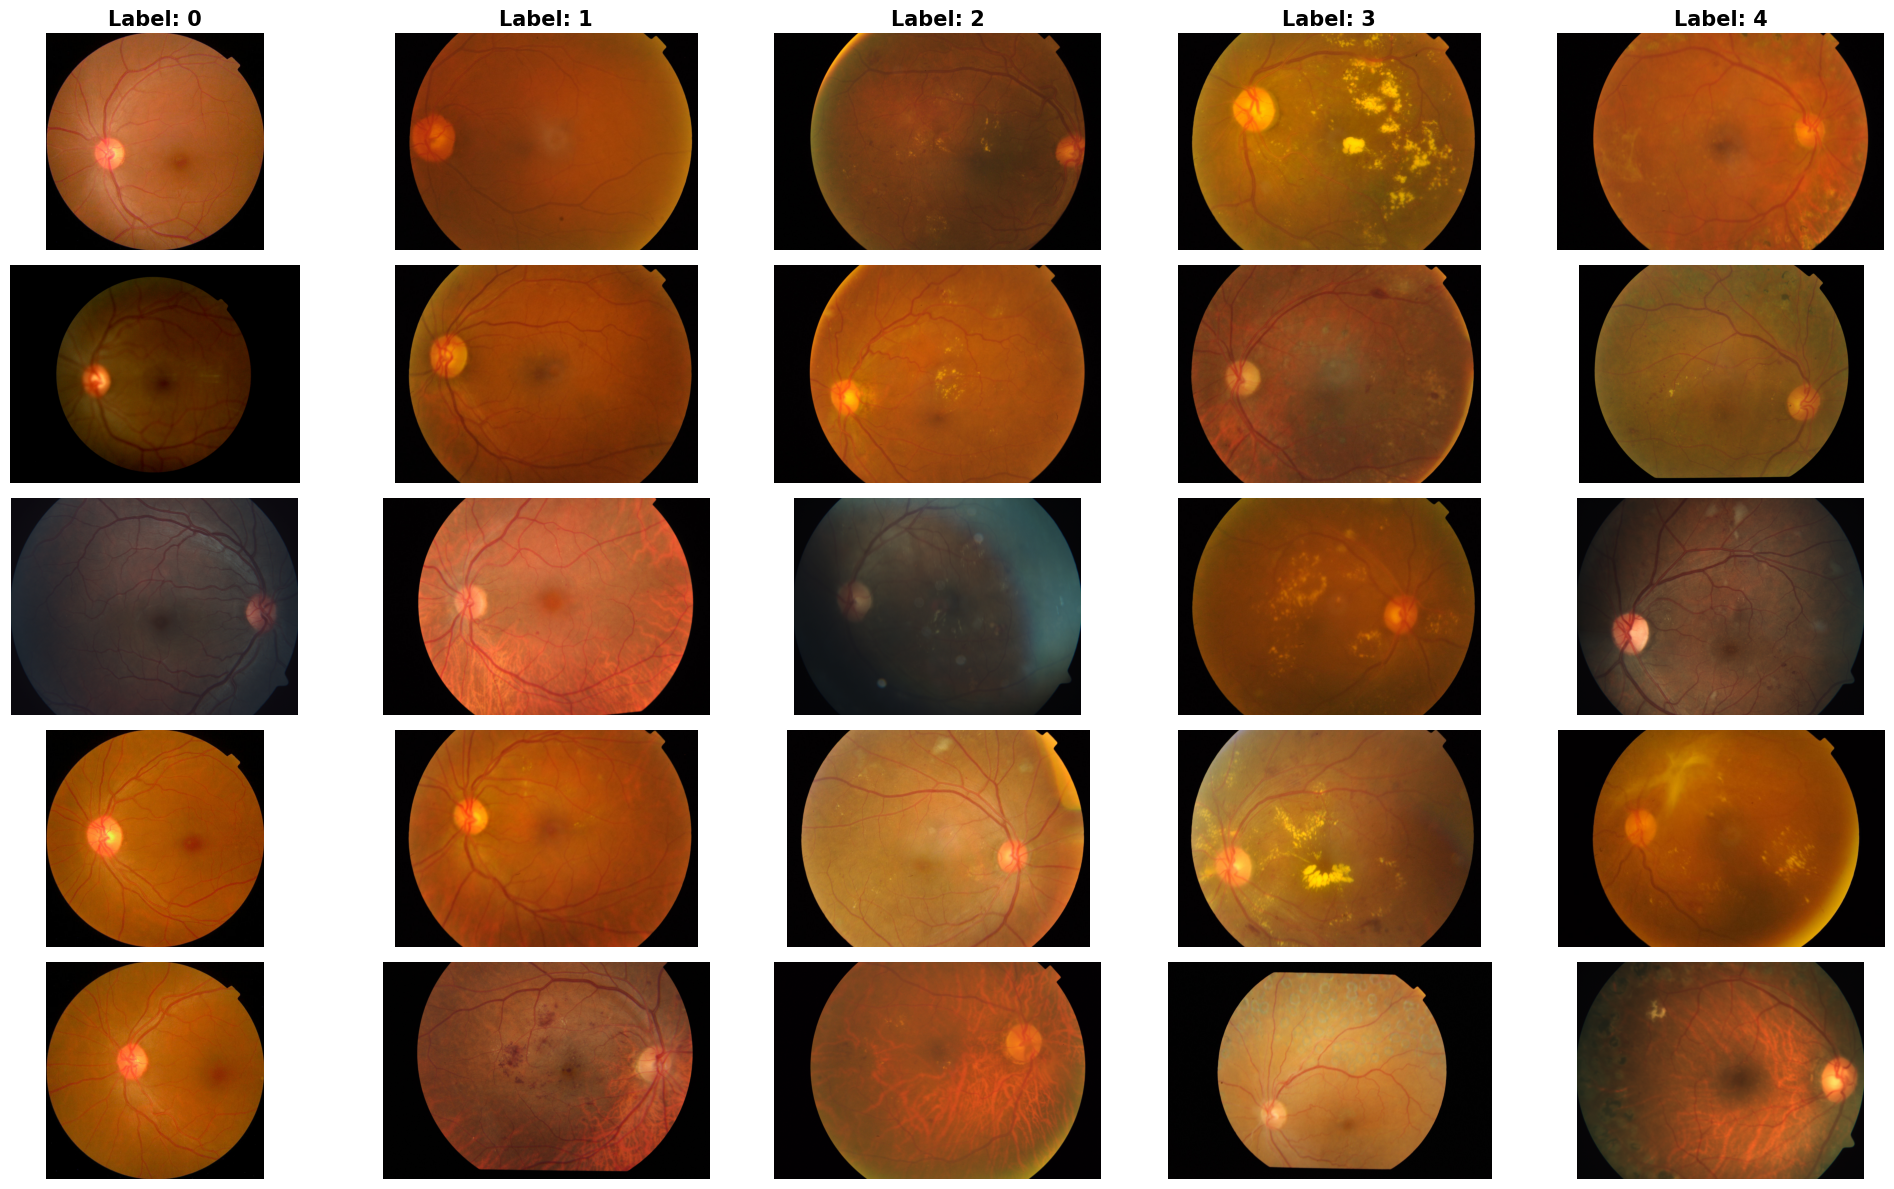

In [9]:
import cv2
import matplotlib.pyplot as plt

# 1. 시각화할 라벨 리스트(0~4)
labels = [0, 1, 2, 3, 4]
num_samples = 5             #라벨당 보여줄 샘플 수

fig, axes = plt.subplots(num_samples, 5, figsize = (20, 12))

for col, label in enumerate(labels):
    # 2. 해당 라벨을 가진 데이터 중 첫번째 행 찾기
    sample_df = train_df[train_df['diagnosis'] == label].head(num_samples)

    for row in range(num_samples):

        img_id = sample_df.iloc[row]['id_code']

        # 3. 이미지 읽어오기
        img_path = f'/content/aptos_data/train_images/{img_id}.png'

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 각 칸에 이미지 표시
        ax = axes[row, col]
        ax.imshow(img)

        # 첫 번째 행에만 라벨 제목 표시
        if row == 0:
            ax.set_title(f"Label: {label}", fontsize=15, fontweight='bold')

        ax.axis('off')

plt.tight_layout()
plt.show()

 ## 핵심 논문 분석 및 모델링 전략 (Key Insights from Literature Review)
 ---
 ### 1. 전처리의 정교화 (Illumination & Contrast Optimization)

 - **문제 정의**: 안저 카메라 특성에 따른 불균일한 조명 및 낮은 대비가 주요 분석 방해 요소로 작용함.

 - **주의 사항**: 단순 리사이징은 정보 손실을 초래하므로 이미지 전체의 밝기 균일화가 필수적임.

 - **해결 전략**: Ben Graham's Preprocessing 또는 CLAHE 기법을 적용하여 혈관 및 병변의 시각적 대비를 극대화함.
---

 ### 2. 해부학적 구조물 오인 방지 (Anatomical Structure Robustness)

 - **문제 정의**: 시신경 유두(Optic Disc) 및 정상 혈관이 주요 병변(삼출물 등)과 시각적 유사성을 가짐.

 - **주의 사항**: 모델이 밝게 빛나는 시신경 유두를 병변으로 오판(False Positive)할 위험이 높음.

 - **해결 전략**: 데이터 증강(Augmentation)을 통한 시신경 위치 변이 부여 및 필요 시 해당 영역 마스킹 기법 검토.
---

 ### 3. 미세 병변 정보 보존 (Resolution Management)

 - **문제 정의**: 초기 징후인 **미세혈관류(Microaneurysms)**는 수 픽셀 단위의 미세한 점 형태임.

 - **주의 사항**: 저해상도($128 \times 128$ 이하) 리사이징 시 픽셀 뭉침으로 인해 초기 단계(Label 1)의 특징이 소실됨.

 - **해결 전략**: 최소 $224 \times 224$ 이상의 입력 해상도 유지 및 고해상도 처리에 특화된 EfficientNet-B4 이상의 아키텍처 채택.
 ---

 ### 4. 다중 병변 탐지 및 손실 함수 설계 (Multi-lesion & Loss Strategy)

 - **문제 정의**: 단일 영상 내 출혈, 삼출물, 신생 혈관 등 다중 병변이 혼재함.

 - **주의 사항**: 특정 특징에 대한 과적합(Overfitting) 방지 및 클래스 간의 위계(Severity) 고려 필요.

-  **해결 전략**: * Attention Mechanism: Grad-CAM을 활용한 모델의 의사결정 영역 시각화 및 검증.Loss Function: 오분류의 가중치를 고려한 Quadratic Weighted Kappa Loss 적용으로 모델의 판별 정밀도 향상.

In [10]:
import numpy as np

def load_ben_color(path, sigmaX=10):
    """
    Ben Graham의 기법을 적용한 이미지 로드 및 전처리 함수
    """

    # 1. 이미지 읽기 및 RGB 변환
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. 검은색 배경 잘라내기 (Auto-Crop)
    image = crop_image_from_gray(image)

    # 3. 모델 입력 사이즈로 리사이즈
    image = cv2.resize(image, (224, 224))

    # 4. Ben Graham's 핵심: 가우시안 블러를 이용한 가중치 합산
    # 원본 이미지와 블러 처리된 이미지의 차이를 이용하여 특징을 강조함
    image = cv2. addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)

    return image

def crop_image_from_gray(img, tol=7):
    # 이미지가 2차원(흑백)인 경우
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]

    # 이미지가 3차원(컬러)인 경우
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        # 유효한 영역이 있는지 확인
        if not np.any(mask):
            return img

        # 마스크를 기반으로 잘라내기
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)

        # 3채널 모두에 적용
        img_cropped = img[np.ix_(rows, cols)]
        return img_cropped

    return img

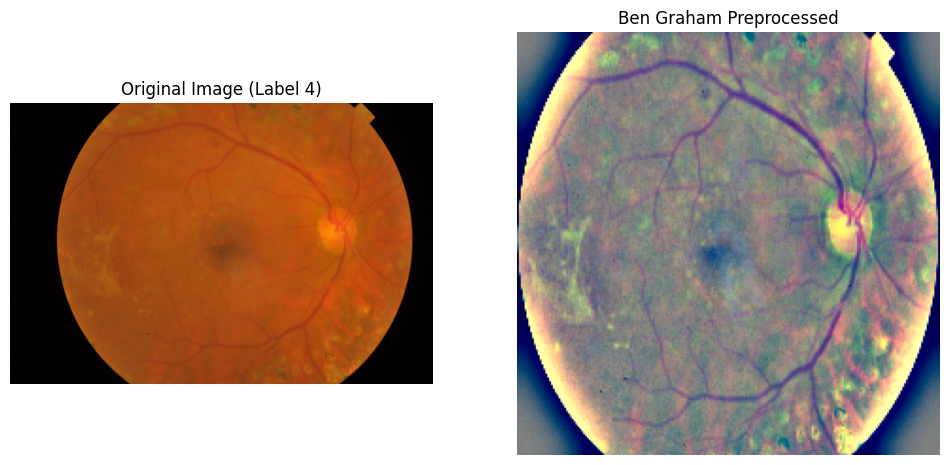

In [11]:
# Label 4의 샘플 하나 선택
sample_id = train_df[train_df['diagnosis'] == 4].iloc[0]['id_code']
img_path = f'/content/aptos_data/train_images/{sample_id}.png'

# 전처리 적용
original_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
preprocessed_img = load_ben_color(img_path)

# 시각화
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image (Label 4)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_img)
plt.title("Ben Graham Preprocessed")
plt.axis('off')
plt.show()

## Dataset & DataLoader 구축

In [12]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

## Dataset 클래스 설계

In [13]:
class APTOSDataset(Dataset):
    def __init__(self, df, image_dir, transform = None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        # 데이터셋의 전체 길이 반환
        return len(self.df)

    def __getitem__(self, idx):
        # 1. 인덱스에 해당하는 이미지 ID와 라벨 추출
        img_name = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']

        # 2. 이미지 경로 생성
        img_path = f"{self.image_dir}/{img_name}.png"

        # 3. 위에서 만든 Ben Graham 전처리 적용 (주의사항)
        # OpenCV 이미지는 [H, W, C] 형태이므로 나중에 Tensor로 바꿀 때 주의해야 함.
        image = load_ben_color(img_path)

        # [H, W, C] -> [C, H, W]로 변경
        # numpy의 transpose를 사용하거나 torch의 permute를 사용
        image = image.transpose(2, 0, 1)

        # 4. 추가 Transform(이미지 증강 등) 적용
        if self.transform:
            image = self.transform(image)

        # 5. 라벨을 텐서 형태로 변환하여 반환
        return torch.tensor(image).float(), torch.tensor(label).long()

## 데이터 분할 (Train / Validation)

In [14]:
from sklearn.model_selection import train_test_split

# 8:2 비율로 학습용, 검증용 데이터 나누기
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['diagnosis'])

print(f"학습용 데이터: {len(train_data)}개")
print(f"검증용 데이터: {len(val_data)}개")

학습용 데이터: 2929개
검증용 데이터: 733개


## DataLoader 생성

In [15]:
from torch.utils.data import DataLoader

# 데이터셋 객체 생성
train_dataset = APTOSDataset(train_data, '/content/aptos_data/train_images')
val_dataset = APTOSDataset(val_data, '/content/aptos_data/train_images')

# 데이터로더 생성 (셔플은 학습용에만 적용)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 잘 작동하는지 한 배치 확인
images, labels = next(iter(train_loader))
print(f"이미지 배치 형태: {images.shape}")
print(f"라벨 배치 형태: {labels.shape}")

이미지 배치 형태: torch.Size([32, 3, 224, 224])
라벨 배치 형태: torch.Size([32])


현재 상태 ([32, 224, 224, 3]): 이는 (Batch, Height, Width, Channel) 순서.

OpenCV나 TensorFlow에서 주로 사용하는 방식

PyTorch 모델 요구 사항 ([32, 3, 224, 224]): 파이토치는 반드시 (Batch, Channel, Height, Width) 순서를 기대

In [16]:
!pip install timm

## Model Architecture

In [17]:
import timm
import torch.nn as nn

class APTOSModel(nn.Module):
    def __init__(self, model_name = 'efficientnet_b0', pretrained=True):
        super(APTOSModel, self).__init__()
        # 1. 사전 학습된(Pretrained) EfficientNet 모델 불러오기
        self.model = timm.create_model(model_name, pretrained=pretrained)

        # 2. 마지막 레이어(Classifier)를 우리 프로젝트에 맞게 수행
        # EfficientNet-B0의 경우 마지막 특징 벡터의 크기가 1280
        in_features = self.model.classifier.in_features

        # 5개의 클래스를 분류하도록 마지막 층을 교체
        self.model.classfier = nn.Linear(in_features, 5)

    def forward(self, x):
        return self.model(x)

# 모델 생성 및 장치(GPU) 할당
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = APTOSModel().to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

APTOSModel(
  (model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2

## 학습 및 검증 엔진 구축

In [18]:
import torch.optim as optim

# 1. 채점 기준: 다중 클래스 분류이므로 CrossEntropyLoss 사용
criterion = nn.CrossEntropyLoss()

# 2. 학습 전략: Adam 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 3. 에폭(Epoch)
epochs = 10

### 학습 함수(Train Function)의 논리 이해

1. optimizer.zero_grad(): 이전 문제의 기억을 지웁니다.

2. output = model(images): 모델에게 사진을 보여주고 답을 찍게 합니다. (Forward)

3. loss = criterion(output, labels): 정답과 비교해서 얼마나 틀렸는지 계산합니다. (Loss)

4. loss.backward(): 틀린 원인을 분석합니다. (Backward)

5. optimizer.step(): 분석한 결과를 바탕으로 뇌(가중치)를 수정합니다. (Update)

## 학습 시작 코드 작성

In [20]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # tqdm 진행 바 설정
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in pbar:
        # 핵심: 이미지와 라벨을 명시적으로 GPU(device)로 보냅니다.
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # 모델 예측
        outputs = model(images)

        # 손실 계산 (이제 둘 다 CUDA 위에 있으므로 에러가 나지 않습니다)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 진행 바에 현재 Loss 표시 (실시간 모니터링용)
        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} 완료 - 평균 Loss: {epoch_loss:.4f}")

Epoch 1/10: 100%|██████████| 92/92 [09:37<00:00,  6.28s/it, loss=0.437]


Epoch 1 완료 - 평균 Loss: 2.1543


Epoch 2/10: 100%|██████████| 92/92 [09:29<00:00,  6.19s/it, loss=0.457]


Epoch 2 완료 - 평균 Loss: 0.5532


Epoch 3/10: 100%|██████████| 92/92 [09:25<00:00,  6.15s/it, loss=0.436]


...

Epoch 8 완료 - 평균 Loss: 0.0619


Epoch 9/10: 100%|██████████| 92/92 [09:23<00:00,  6.12s/it, loss=0.0782]


Epoch 9 완료 - 평균 Loss: 0.0570


Epoch 10/10: 100%|██████████| 92/92 [09:24<00:00,  6.13s/it, loss=0.0362]

Epoch 10 완료 - 평균 Loss: 0.0525


In [21]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import numpy as np

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, lables = images.to(device), labels.to(device)
            outputs = model(images)

            # 가장 높은 확률을 가진 클래스 선택
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Quadratic Weighted Kappa 계산
    kappa = cohen_kappa_score(all_labels, all_preds, weights = 'quadratic')
    # 정확도 계산
    accuracy = np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

    return kappa, accuracy, all_labels, all_preds

In [22]:
# 학습 완료 후

kappa, acc, y_true, y_pred = evaluate(model, val_loader, device)
print(f"Validation Kappa: {kappa:.4f}, Accuracy: {acc:.4f}")

Evaluating: 100%|██████████| 23/23 [02:22<00:00,  6.19s/it]

Validation Kappa: 0.8508, Accuracy: 0.8022


## Quadratic Weighted Kappa, QWK
---

### 1. "우연히 맞힌 점수"를 빼주는 지표
단순 정확도는 모델이 아무 생각 없이 찍어서 맞힌 것까지 점수에 포함. 하지만 Kappa는 **"모델의 실력"**과 "우연히 맞힌 확률" 사이의 간극을 계산

- Kappa = 1: 모델이 완벽하게 정답을 맞힘.

- Kappa = 0: 모델이 그냥 무작위로 찍은 수준과 다를 바 없음.

- Kappa < 0: 찍는 것보다 못한 성능 (거의 발생하지 않음).

---

### 2. "얼마나 틀렸는가"의 무게 (Weighting)
의료 데이터에서는 **'어떻게 틀렸는가'**가 매우 중요.
QWK는 틀린 정도에 따라 벌점을 다르게 줌.

- 가벼운 실수: 실제 2단계를 모델이 1단계라고 진단함 (벌점 적음)

- 치명적 실수: **실제 4단계(실명 위기)**를 모델이 **0단계(정상)**라고 진단함 (벌점 매우 큼)

## 오차 행렬 (Confusion Matrix) 시각화

In [23]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


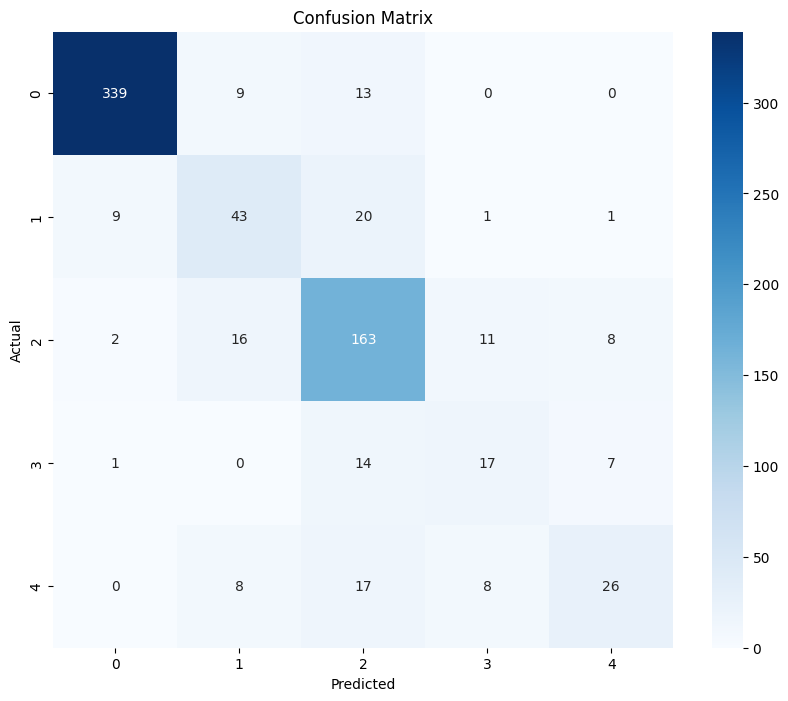

In [24]:
plot_confusion_matrix(y_true, y_pred)

In [25]:
# 모델 저장 폴더 생성
os.makedirs('./models', exist_ok=True)
save_path = './models/aptos_efficientnet_b0_kappa85.pth'

# 모델의 가중치 저장
torch.save(model.state_dict(), save_path)
print(f"모델 저장 완료: {save_path}")

모델 저장 완료: ./models/aptos_efficientnet_b0_kappa85.pth


In [27]:
!pip install grad-cam  # 필요 시 설치

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=99e05312e1d650b62e53a14aa35d182e7ed316c0e77a7abcc59bcfd3b129712d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


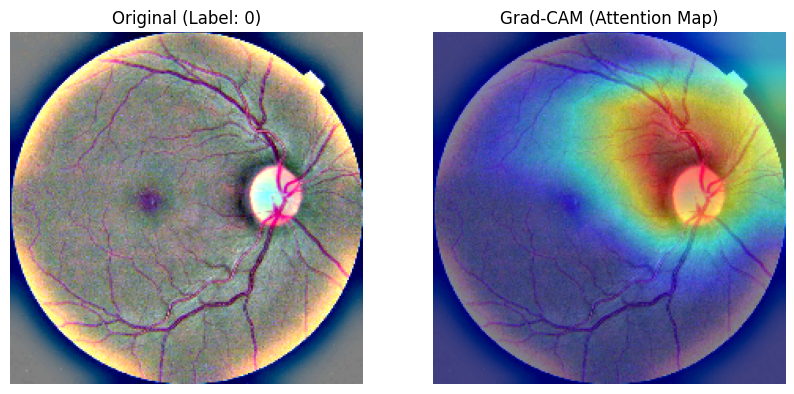

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 라이브러리 버전에 따라 ClassifierTarget 위치가 다를 수 있어 예외 처리를 추가.
try:
    from pytorch_grad_cam.utils.model_targets import ClassifierTarget
except ImportError:
    # 최신 버전에서는 위치가 다를 수 있으므로 직접 정의하거나 다른 경로 확인
    class ClassifierTarget:
        def __init__(self, category):
            self.category = category
        def __call__(self, model_output):
            if len(model_output.shape) == 1:
                return model_output[self.category]
            return model_output[:, self.category]

def display_gradcam(model, input_tensor, target_label):
    model.eval()

    # 1. 시각화할 마지막 Conv 레이어 지정 (EfficientNet-B0 기준)
    # 모델 구조에 따라 model.model.conv_head 또는 model.model.act2
    target_layers = [model.model.conv_head]

    # 2. Grad-CAM 객체 생성
    cam = GradCAM(model=model, target_layers=target_layers)

    # 3. 타겟 라벨 지정
    targets = [ClassifierTarget(target_label)]

    # 4. CAM 생성 (배치 차원 추가 필요)
    input_batch = input_tensor.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # 5. 원본 이미지 시각화용 전처리 (Normalization 해제)
    img_np = input_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-7)

    # 6. 히트맵 합성
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # 7. 결과 출력
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original (Label: {target_label})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM (Attention Map)")
    plt.axis('off')
    plt.show()

# 실행: 검증 데이터셋의 10번째 샘플로 테스트
sample_img, sample_label = val_dataset[10]
display_gradcam(model, sample_img, sample_label)

## 1. 프로젝트 개요 (Overview)

- 주제: EfficientNet 기반 당뇨망막병증(DR) 다중 클래스 분류 및 진단 근거 시각화

- 목표: 안저 영상을 분석하여 질병의 중증도(0~4단계)를 판별하고 진단 신뢰성 확보

- 핵심 성과: Quadratic Weighted Kappa 0.8508 달성 (상위권 성능)


## 2. 주요 문제 해결 및 전략 (Key Problem Solving)

2-1. 시각적 노이즈 및 장비 편차 해결
- 문제점 (Pain Point): 촬영 장비 및 환경에 따른 조명/색상 불균형이 심하며, 안구 외 검은 배경 영역이 불필요한 연산 자원 소모 유발.

- 해결 방안 (Action): Ben Graham's Preprocessing 기법(Auto-Crop 및 가우시안 블러 기반 대비 향상)을 적용하여 이미지 표준화 수행.

- 결과 (Result): 장비 간 편차를 제거하고 혈관 및 미세 병변의 대비를 극대화하여 모델의 특징 추출 효율성 증대.

2-2. 학습 데이터 불균형 대응
- 문제점 (Pain Point): 정상(Label 0) 데이터가 전체의 50% 이상을 차지하는 심각한 불균형으로 인해 모델이 다수 클래스에 편향될 위험 존재.

- 해결 방안 (Action): Weighted CrossEntropy Loss를 도입하여 빈도가 낮은 희귀 클래스에 대해 더 높은 손실 가중치 부여.

- 결과 (Result): 모델이 데이터 수가 적은 Label 3(Severe), Label 4(Proliferative) 단계의 특징을 더욱 정밀하게 학습하도록 유도.

2-3. 미세 병변 정보 손실 방지
- 문제점 (Pain Point): 초기 진단의 핵심인 미세혈관류(Microaneurysms)는 크기가 매우 작아 저해상도 리사이징 시 픽셀 뭉침으로 인해 정보가 소실됨.

- 해결 방안 (Action): EfficientNet-B0 아키텍처를 채택하고 입력 해상도를 최적화하여 고해상도 이미지 내 미세 특징 보존.

- 결과 (Result): 육안으로 구분이 어려운 초기 단계(Label 1)의 특징을 효과적으로 포착하여 분류 정확도 향상.

2-4. 모델 판단 근거의 투명성 확보
- 문제점 (Pain Point): 딥러닝 모델의 '블랙박스' 특성으로 인해 모델이 이미지의 어느 부위를 보고 진단을 내렸는지에 대한 의학적 근거 확인 불가.

- 해결 방안 (Action): Grad-CAM(Gradient-weighted Class Activation Mapping) 시각화 기법 구현.

- 결과 (Result): 모델이 실제 병변 부위에 집중하고 있음을 히트맵으로 증명하여 진단 결과에 대한 설명 가능성(Explainable AI, XAI) 확보.

## 3. 결과 분석 및 인사이트 (Insight)
Kappa Score 0.85: 단순 정확도보다 높은 Kappa 점수를 통해 모델이 질병의 위계(Severity)를 논리적으로 이해하고 있음을 입증.

Error Analysis: 오차 행렬 분석 결과, 1단계와 2단계 사이의 미세한 혼동을 발견. 향후 더 높은 해상도의 모델(B4 이상)이나 세부 병변 마스킹을 통한 개선 가능성 제시.